# 📊 Task 2: Data Analysis and Sales Performance EDA
**Author:** Adarsh Pandey  
**Company:** Main Flow Services and Technologies Pvt. Ltd.

This notebook covers two projects:
- **Project 1:** General EDA using Global Superstore dataset (CSV)
- **Project 2:** Sales Performance Analysis using sales_data.csv


## 📁 Project 1: General EDA

In [3]:
# Install dependencies (if running locally)
# !pip install pandas numpy matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')

### 🔹 Load Dataset: Global Superstore (CSV Format)

In [5]:
df1 = pd.read_csv('Global_Superstore.csv', encoding='ISO-8859-1')
df1.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


### 🔹 Data Cleaning

In [6]:
# Drop rows with missing values
df1 = df1.dropna()

# Remove duplicates
df1.drop_duplicates(inplace=True)

# Handle outliers using IQR
num_cols = df1.select_dtypes(include=np.number).columns
for col in num_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    df1 = df1[(df1[col] >= Q1 - 1.5*IQR) & (df1[col] <= Q3 + 1.5*IQR)]
df1.shape

(114, 24)

### 🔹 Statistical Summary

In [7]:
df1.describe()

,ï»¿Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000,114.000000
mean,36104.061404,52770.640351,47.488772,3.061404,0.101754,9.482368,4.134737
std,2904.290858,34395.331913,55.538198,1.553102,0.103036,12.244370,3.641434
min,31562.000000,2920.000000,2.220000,1.000000,0.000000,-16.960000,1.070000
25%,33380.250000,18018.000000,13.895000,2.000000,0.000000,2.265000,1.520000
50%,36273.500000,59955.000000,24.745000,3.000000,0.100000,5.680000,2.155000
75%,38903.500000,90004.000000,57.502500,4.000000,0.200000,13.212500,5.490000
max,41032.000000,98198.000000,304.230000,7.000000,0.300000,48.380000,13.930000


### 🔹 Correlation Heatmap

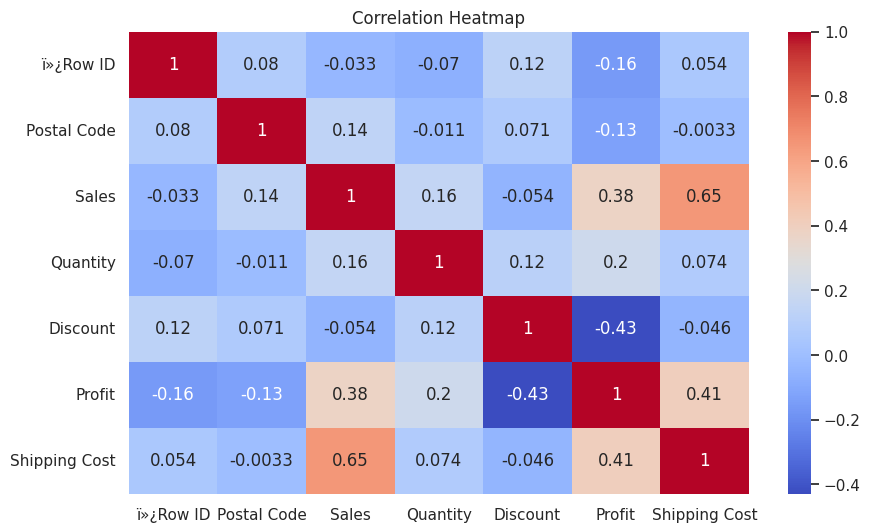

In [9]:
plt.figure(figsize=(10,6))
# Select only numerical features for correlation
numerical_df = df1.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### 🔹 Histograms & Boxplots

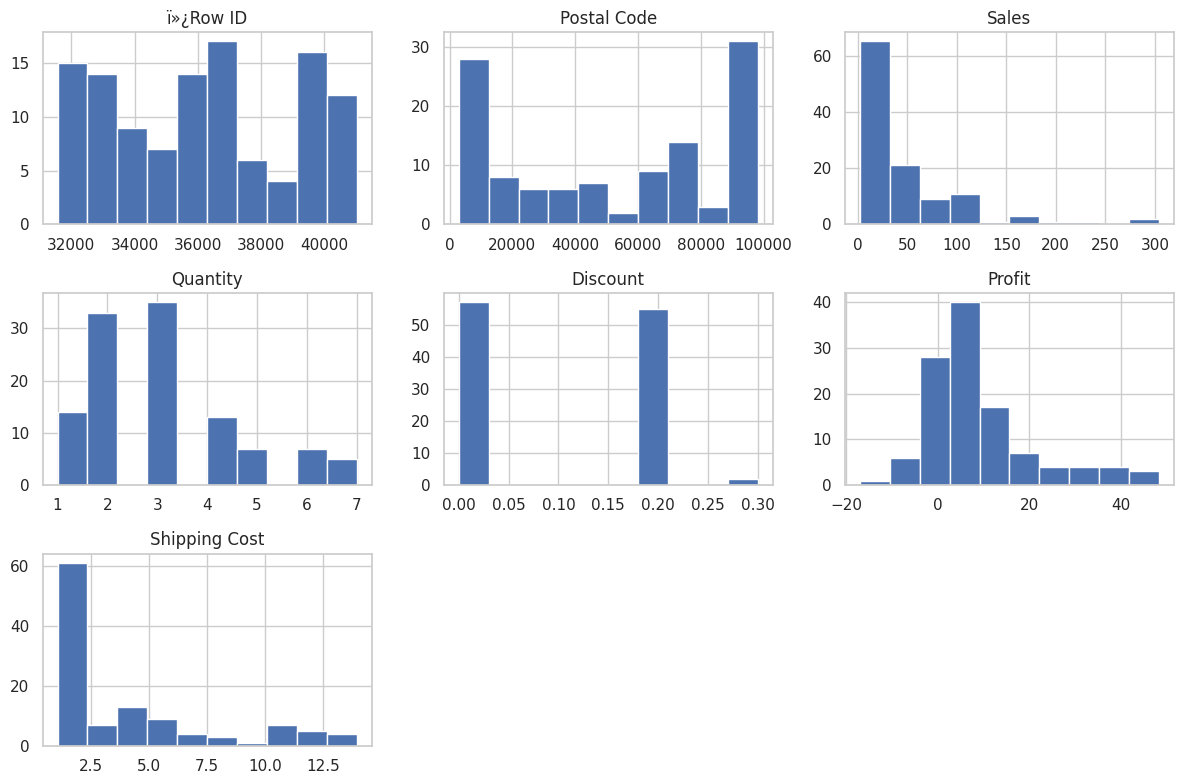

In [10]:
df1.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

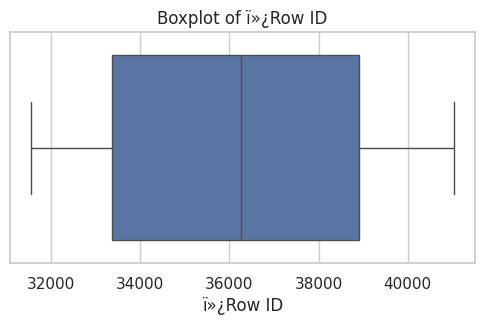

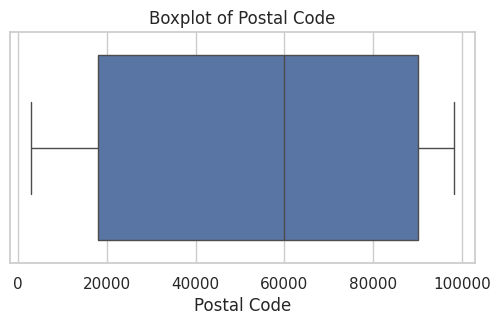

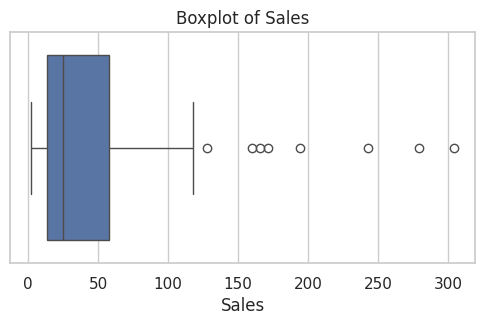

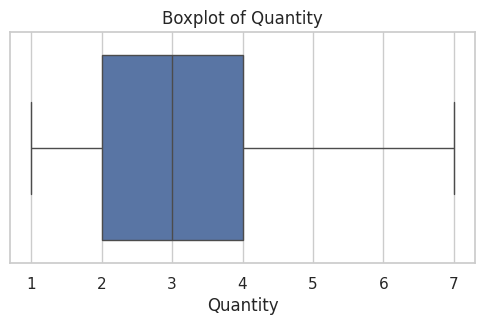

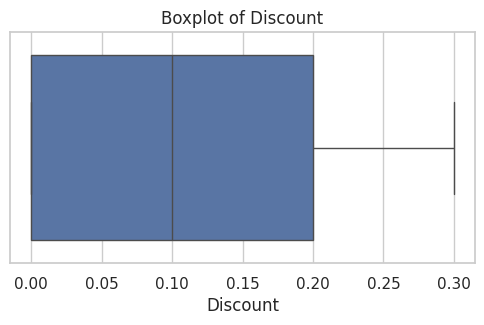

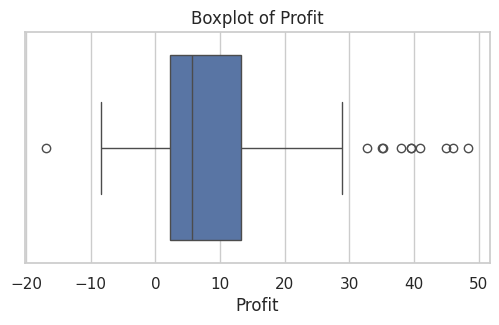

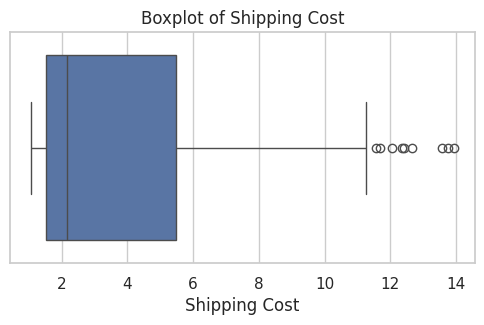

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df1[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## 📁 Project 2: Sales Performance Analysis

In [39]:
sales_df = pd.read_csv('/sales_data.csv', encoding='latin1') # or 'ISO-8859-1' or 'cp1252'
sales_df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


### 🔹 Data Cleaning

In [40]:
# Remove duplicates and handle missing values
sales_df.drop_duplicates(inplace=True)
sales_df.fillna(sales_df.mean(numeric_only=True), inplace=True)

In [43]:
sales_df['ORDERDATE'] = pd.to_datetime(sales_df['ORDERDATE'])


### 🔹 Time Series Plot: Sales Over Time

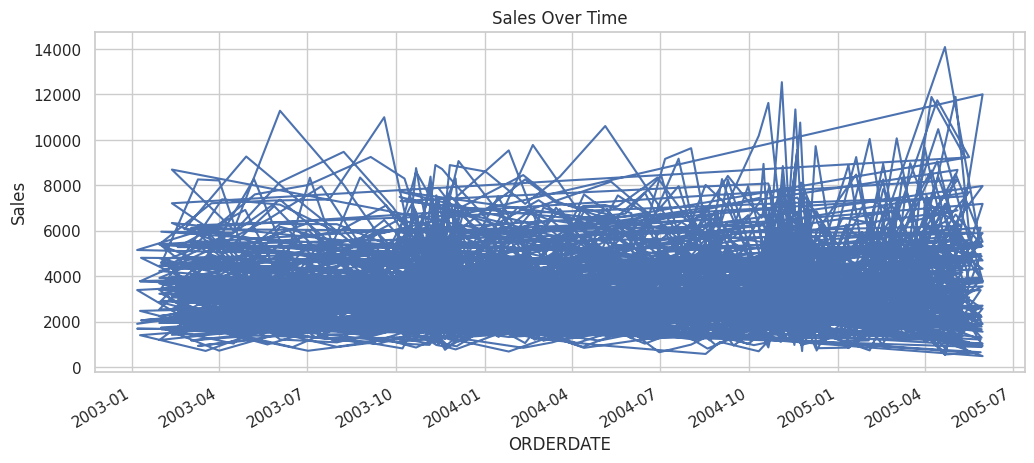

In [46]:
sales_df.set_index('ORDERDATE')['SALES'].plot(figsize=(12,5), title='Sales Over Time')
plt.ylabel('Sales')
plt.show()


### 🔹 Scatter Plot: Profit vs Discount

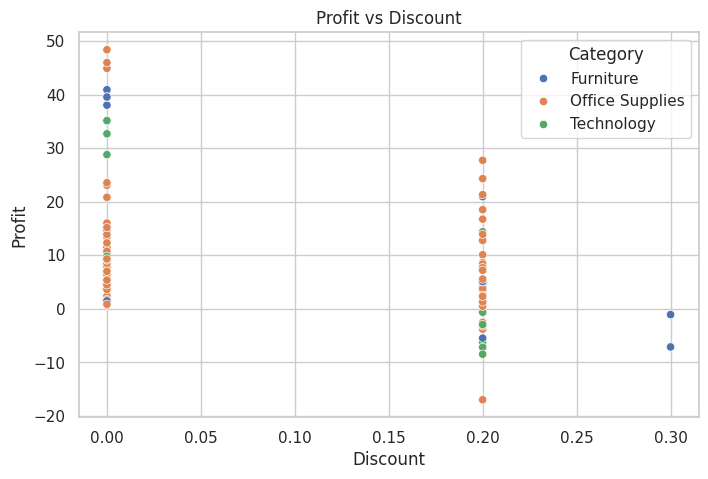

In [53]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df1, x='Discount', y='Profit', hue='Category')
plt.title('Profit vs Discount')
plt.show()


### 🔹 Sales Distribution by Region and Category

In [55]:
print(sales_df.columns.tolist())


['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


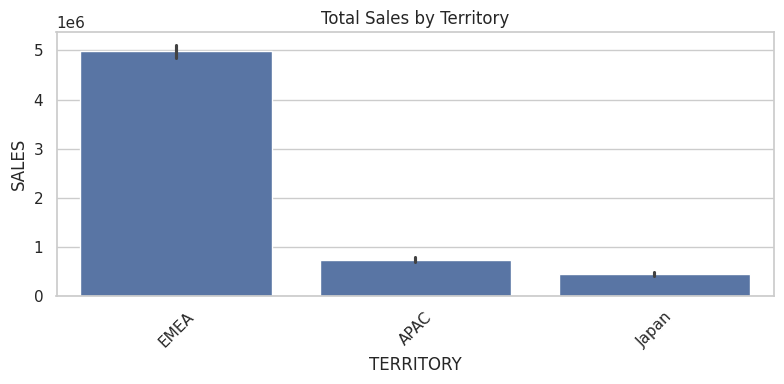

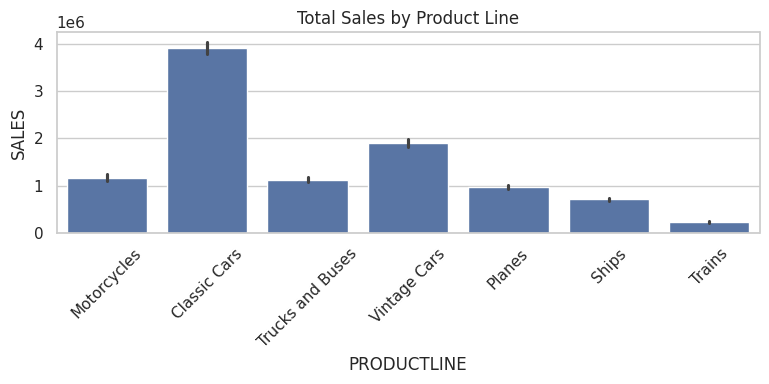

In [56]:
# Clean column names
sales_df.columns = sales_df.columns.str.strip()

# Total Sales by Territory (or REGION if exists)
plt.figure(figsize=(8,4))
sns.barplot(data=sales_df, x='TERRITORY', y='SALES', estimator=sum)
plt.title('Total Sales by Territory')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Total Sales by Product Line
plt.figure(figsize=(8,4))
sns.barplot(data=sales_df, x='PRODUCTLINE', y='SALES', estimator=sum)
plt.title('Total Sales by Product Line')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 🔹 Linear Regression: Predict Sales from Profit & Discount

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Clean column names
df1.columns = df1.columns.str.strip()

# Prepare data
X = df1[['Profit', 'Discount']]
y = df1['Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
print('R2 Score:', r2_score(y_test, predictions))
print('MSE:', mean_squared_error(y_test, predictions))


R2 Score: 0.07559234011826077
MSE: 4500.315729723332


### ✅ Insights & Recommendations
- High discounts negatively affect profit; optimize discounts.
- Focus on top-performing regions and product categories.
- Use predictive modeling to identify future sales opportunities.